# Pauta Auxiliar 4: Listas Enlazadas y Árboles Binarios

**Auxiliares: Sebastián Acuña, Daniela Espinoza, Cristián Llull, Benjamín Osses, Anish Samtani y Marcelo Zamorano<br>
Profesores: Nelson Baloian, Iván Sipirán, Patricio Poblete<br>
Curso: CC3001 Algoritmos y Estructuras de Datos**


In [ ]:
# Se nombraran los nodos de una lista enlazada como LNodo
# Se nombraran los nodos de una lista enlazada como ANodo
# Se nombraran los nodos de una lista doble enlazada como DNodo

class LNodo:
  def __init__(self, val = 0, sig = None):
    self.val = val
    self.sig = sig

class ANodo:
  def __init__(self, val = 0, izq = None, der = None):
    self.val = val
    self.izq = izq
    self.der = der

class DNodo:
  def __init__(self, val = 0, prev = None, sig = None):
    self.val = val
    self.prev = prev
    self.sig = sig

# Problema 1

Sean `lista1` y `lista2`, listas enlazadas ordenadas. Junte las listas en una ordenada y retorne la cabeza de la nueva lista.

In [ ]:
def unir_listas(lista1, lista2):
  if not lista1: return lista2
  if not lista2: return lista1

  # LNodo para empezar
  nodo_inicial = LNodo()
  ptr = nodo_inicial
  ptr1 = lista1
  ptr2 = lista2
  while ptr1 and ptr2:
    # si el LNodo de lista 1 es menor al LNodo en lista 2
    if ptr1.val < ptr2.val:
      # el siguiente es el LNodo de lista 1
      ptr.sig = ptr1
      # avanzo en la lista 1
      ptr1 = ptr1.sig
    else:
      ptr.sig = ptr2
      ptr2 = ptr2.sig
    # avanzo al siguiente en la lista unida
    ptr = ptr.sig

  # si todavia quedan LNodos de la lista 1
  if ptr1:
    # uno los que quedan
    ptr.sig = ptr1
  elif ptr2:
    ptr.sig = ptr2

  # el primer LNodo era solo para conectar
  return nodo_inicial.sig

In [ ]:
# Ejemplo enunciado
lista1 = LNodo(1, LNodo(2, LNodo(4)))
lista2 = LNodo(1, LNodo(3, LNodo(4)))
nueva_cabeza = unir_listas(lista1, lista2)

# imprimimos la lista para revisar
ptr = nueva_cabeza
while ptr is not None:
  print(ptr.val)
  ptr = ptr.sig

1
1
2
3
4
4


# Problema 2
Implemente las siguientes operaciones sobre un árbol binario cualquiera:

Hay dos posibles soluciones:
- **Usando `Nodoe`:** esta oppción implica crear dos clases: `Nodoi` y `Nodoe`. Cuando se recorre recursivamente el árbol, una vez que accedemos al `Nodoe` (se implementan las funciones con el mismo nombre tanto en `Nodoi` como `Nodoe`), este retorna el **caso base**.
- **Usando nodos externos = `None`:** en este caso, cuando vemos que algún hijo es `None` (un nodo externo) aplicamos el **caso base**.

Luego, la única diferencia es este `if` adicional en el caso de usar `None`. `Nodoe` es más "elegante", pero ambos son válidos y puede variar la complejidad de programación.

En esta pauta usaremos la implementación con nodos externos como `None`. Se sugiere implementar los mismos métodos para el caso usando `Nodoe`.

In [ ]:
class Nodo:
  def __init__(self, val, izq=None, der=None):
    self.val = val
    self.izq = izq  # Default es None: es decir, inicialmente son "nodos externos"
    self.der = der

In [ ]:
def obtenerNumero(nodo):
  #Caso base
  if nodo is None:
    return 0
  else:
    return 1 + obtenerNumero(nodo.izq) + obtenerNumero(nodo.der)

def obtenerMaximo(nodo):
  if nodo is None:
    return -np.inf
  else:
    max_hijos = max(obtenerMaximo(nodo.izq), obtenerMaximo(nodo.der))
    return max(max_hijos, nodo.val)

def obtenerSuma(nodo):
  #caso base
  if nodo is None:
    return 0
  else:
    return nodo.val + obtenerSuma(nodo.izq) + obtenerSuma(nodo.der)

def obtenerAltura(nodo):
  #caso base
  if nodo is None:
    return 0 #Puede ser 1 dependiendo de la definición de altura
  else:
    return 1+max(obtenerAltura(nodo.izq), obtenerAltura(nodo.der))

# Propuestos;
def imprimirPreorden(nodo):
  if nodo is None:
    print('', end='')
  else:
    print(nodo.val, end=' ')
    imprimirPreorden(nodo.izq)
    imprimirPreorden(nodo.der)

def imprimirPostorden(nodo):
  if nodo is None:
    print('', end='')
  else:
    imprimirPostorden(nodo.izq)
    imprimirPostorden(nodo.der)
    print(nodo.val, end=' ')


Implementamos la clase ArbolBinario (el "wrapper").

In [ ]:
class ArbolBinario:
  def __init__(self, raiz=None):
    self.raiz = raiz

  def obtenerNumeroNodos(self):
    return obtenerNumero(self.raiz)

  def obtenerMaximoValor(self):
    return obtenerMaximo(self.raiz)

  def obtenerSumaArbol(self):
    return obtenerSuma(self.raiz)

  def obtenerAlturaArbol(self):
    return obtenerAltura(self.raiz)

  def imprimirPostorden(self):
    return imprimirPostorden(self.raiz)
  def imprimirPreorden(self):
    return imprimirPreorden(self.raiz)

  def dibujar(self):
    BTdraw = aed.BinaryTreeDrawer(fieldData="val", fieldLeft="izq", fieldRight = "der", drawNull=True)
    BTdraw.draw_tree(self, "raiz")

Probamos visualmente que todo esté en orden.

In [ ]:
!pip install aed_utilities

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.4 MB/s eta 0:00:00
  Created wheel for aed_utilities: filename=aed_utilities-0.5.8-py3-none-any.whl size=4685 sha256=f5364d31f9f060014cf33cca8b6708496843f43c2b8864264aecd73561d57de5
  Stored in directory: /root/.cache/pip/wheels/02/0f/f2/2fa6083d3c36dceca709ed81ab931b4f03b9f9ede17c974ea9
Successfully built aed_utilities


In [ ]:
import aed_utilities as aed
import numpy as np

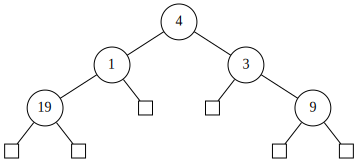

In [ ]:
arbolito = ArbolBinario(
    Nodo(4,
         Nodo(1,
              Nodo(19)
              ),
         Nodo(3, None, Nodo(9))
         )
     )
arbolito.dibujar()

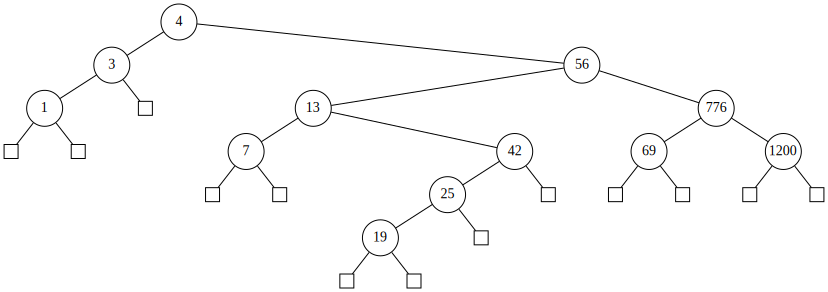

In [ ]:
arbolote = ArbolBinario(Nodo(4, Nodo(3,Nodo(1)), Nodo(56, Nodo(13, Nodo(7), Nodo(42, Nodo(25, Nodo(19)))), Nodo(776, Nodo(69), Nodo(1200)))))
arbolote.dibujar()

a) Obtener el número de nodos.

In [ ]:
print("Los nodos el el árbol chico son: " + str(arbolito.obtenerNumeroNodos())   )
print("Los nodos el el árbol grande son: " + str(arbolote.obtenerNumeroNodos())  )

Los nodos el el árbol chico son: 5
Los nodos el el árbol grande son: 12


b) Obtener el máximo valor.

In [ ]:
print("El máximo valor de un nodo en el árbol chico es: " + str(arbolito.obtenerMaximoValor())  )
print("El máximo valor de un nodo en el árbol grande es: " + str(arbolote.obtenerMaximoValor())  )

El máximo valor de un nodo en el árbol chico es: 19
El máximo valor de un nodo en el árbol grande es: 1200


c) Obtener la suma de todos los valores.

In [ ]:
print("La suma total de los nodos en el árbol chico es: " + str( arbolito.obtenerSumaArbol())  )
print("La suma total de los nodos en el árbol grande es: " + str( arbolote.obtenerSumaArbol())  )

La suma total de los nodos en el árbol chico es: 36
La suma total de los nodos en el árbol grande es: 2215


d) Obtener la altura del árbol.

In [ ]:
print("El número de pisos del árbol chico es: " + str( arbolito.obtenerAlturaArbol())  )
print("El número de pisos del árbol chico es: " + str( arbolote.obtenerAlturaArbol())  )

El número de pisos del árbol chico es: 3
El número de pisos del árbol chico es: 6


e) **Propuesto:** Implemente ahora los métodos para imprimir en Preorden y Postorden.

In [ ]:
arbolito.imprimirPreorden()
print()
arbolito.imprimirPostorden()
print()
print()
arbolote.imprimirPreorden()
print()
arbolote.imprimirPostorden()

4 1 19 3 9 
19 1 9 3 4 

4 3 1 56 13 7 42 25 19 776 69 1200 
1 3 7 19 25 42 13 69 1200 776 56 4 

f) **Propuesto:** Calcule el diámetro (el largo camino más largo entre dos nodos cualquiera) de un árbol

In [ ]:
def diametro(raiz: ANodo):
  def diametro_recursivo(raiz):
    if raiz is None:
      return (0, 0)

    diametro_izq, altura_izq = diametro_recursivo(raiz.izq)
    diametro_der, altura_der = diametro_recursivo(raiz.der)
    diametro_propio = altura_izq + altura_der

    return (max(diametro_propio, diametro_izq, diametro_der),
            1 + max(altura_izq, altura_der))

  return diametro_recursivo(raiz)[0]

In [ ]:
# Prueba:
#     1
#    / \
#   2   3
#  / \
# 4   5
raiz = ANodo(1, ANodo(2, ANodo(4), ANodo(5)), ANodo(3))
assert diametro(raiz) == 3

# Problema 3

Dado un árbol binario encuentre el ACB de dos nodos de un árbol.
Según Wikipedia, el ACB se define como: 'El ancestro común más bajo entre dos nodos v y w se define como el nodo más bajo en el árbol que tiene a v y w como descendientes (donde se permite a un nodo ser descendiente de él mismo).'

In [ ]:
# version explicita (más entendible)
def acb_exp(raiz: ANodo, nodo_p: ANodo, nodo_q: ANodo):
    # Bajamos el árbol al final y subimos propagando hacia arriba 3 datos:
    # 1. Si se encontro el nodo_p
    # 2. Si se encontro el nodo_q
    # 3. El primer nodo donde los dos fueron encontrados que es el ACB, None si no se tiene
    def acb_recursivo(raiz: ANodo, nodo_p: ANodo, nodo_q: ANodo):
        # caso base
        if not raiz:
            return False, False, None

        # bajamos en el arbol, obteniendo información en la subida
        nodo_p_en_izq, nodo_q_en_izq, acb_izq = acb_recursivo(raiz.izq, nodo_p, nodo_q)
        nodo_p_en_der, nodo_q_en_der, acb_der = acb_recursivo(raiz.der, nodo_p, nodo_q)

        nodo_p_encontrado = nodo_p_en_izq or nodo_p_en_der or raiz == nodo_p
        nodo_q_encontrado = nodo_q_en_izq or nodo_q_en_der or raiz == nodo_q

        # el ACB que se propago hacia arriba
        acb = acb_izq if acb_izq else acb_der
        # si recien en este nivel se encontraron ambos
        if not acb and nodo_p_encontrado and nodo_q_encontrado:
            acb = raiz

        return nodo_p_encontrado, nodo_q_encontrado, acb

    # retornamos solo el ACB
    return acb_recursivo(raiz, nodo_p, nodo_q)[2]


In [ ]:
# version directa, con tracking indirecto de p y q
# Usar una sola variable para prograpagar información hacia arriba
# Si no se tiene el ACB, no se ha encontrado ni p ni q entonces propagamos None
# Si encontramos el ACB propagamos el ACB
# Si encontramos p o q propagamos este mismo
def acb_sim(raiz: ANodo, nodo_p: ANodo, nodo_q: ANodo):
    if not raiz or raiz == nodo_p or raiz == nodo_q:
        return raiz

    # post orden
    izq = acb_sim(raiz.izq, nodo_p, nodo_q)
    der = acb_sim(raiz.der, nodo_p, nodo_q)

    # si ambos lados devuelven algo, significa que p y q están en subárboles
    # distintos por lo tanto, este nodo es el ACB

    # Notese que si p o q es el MCA, al subir el ultimo en encontrarse se propaga
    # sin cambios como MCA
    if izq and der:
        return raiz

    # si solo recibimos uno puede ser que se encontro p, q o el MCA
    # por ende lo retornamos para propagar la información
    return izq if izq else der

In [ ]:
# Ejemplo enunciado
raiz = ANodo(3,
             ANodo(5,
                   ANodo(6),
                   ANodo(2,
                         ANodo(7),
                         ANodo(4))),
             ANodo(1,
                   ANodo(0),
                   ANodo(8)))

# MCA de 5 y 1 es 3
assert acb_sim(raiz, raiz.izq, raiz.der).val == ANodo(3).val
assert acb_exp(raiz, raiz.izq, raiz.der).val == ANodo(3).val

# MCA de 5 y 4 es 5
assert acb_sim(raiz, raiz.izq, raiz.izq.der.der).val == ANodo(5).val
assert acb_exp(raiz, raiz.izq, raiz.izq.der.der).val == ANodo(5).val

# Problema 4
Supongamos que cada nodo de un árbol binario representa un ingrediente de un anticucho. Queremos "ensartar" los ingredientes en un palito de forma ordenada, formando una lista doblemente enlazada.

Para ello, se deben reutilizar los punteros izq y der como prev y next. El orden en que se colocan los ingredientes en el anticucho corresponde al recorrido in-order del árbol. El primer ingrediente (el nodo más a la izquierda) será el inicio del anticucho.

In [ ]:
import aed_utilities as aed

#######################################################################
# Esto lo consideramos como «asumido»
class NodoLDE:  # Nodo lista doble enlace
    def __init__(self, prev, info, sgte):
        self.prev=prev
        self.info=info
        self.sgte=sgte

class Lista_doble_enlace:
    def __init__(self):
        self.cabecera=NodoLDE(None,0,None)
        self.cabecera.prev=self.cabecera
        self.cabecera.sgte=self.cabecera

    def insertar_despues_de(self,p,info): # inserta después de nodo p
        r=p.sgte
        p.sgte=r.prev=NodoLDE(p,info,r)

    def eliminar(self,p): # elimina el nodo p
        assert p is not self.cabecera
        (p.prev.sgte,p.sgte.prev)=(p.sgte,p.prev)

    def k_esimo(self,k): # retorna k-esimo nodo, o None si fuera de rango
        p=self.cabecera
        j=0
        while True:
            if j==k:
                return p
            p=p.sgte
            if p is self.cabecera:
                return None
            j+=1

    def ascendente(self):
        p=self.cabecera.sgte
        while p is not self.cabecera:
            yield p.info
            p=p.sgte

    def descendente(self):
        p=self.cabecera.prev
        while p is not self.cabecera:
            yield p.info
            p=p.prev

    def get_primero(self):
        return self.cabecera.sgte

    def get_ultimo(self):
        return self.cabecera.prev

    # Para dibujar una lista doblemente enlazada, es necesario además definir el nombre del campo del puntero hacia atrás.
    # El parámetro para definir ese campo es "fieldReverseLink". Por default, este campo es None.
    def dibujar(self):
        lld=aed.LinkedListDrawer(fieldHeader="cabecera", fieldData="info", fieldLink="sgte", fieldReverseLink="prev")
        lld.draw_double_linked_list(self)


class NodoArbol:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

class ArbolOLDE:
    def __init__(self,raiz=None):
        if raiz is None:
            self.raiz = NodoArbol(NodoArbol(NodoArbol(NodoArbol(None, 0, None),
                                                      1,
                                                      NodoArbol(None, 2, None)),
                                            3,
                                            #NodoArbol(None, 4, None)),
                                            None),
                                  5,
                                  NodoArbol(None,
                                            6,
                                            NodoArbol(NodoArbol(None, 7, None),
                                                      8,
                                                      NodoArbol(None, 9, None))))
        else:
            self.raiz = raiz

    #######################################################################
    # Aquí empezamos nuestra solución
    #######################################################################

    # Solución:
    def a_lista_doble_enlace(self):
        self.cabecera = NodoArbol(None, 0, None)
        if self.raiz is None:
            print('raíz es None')
            self.cabecera.der = self.cabecera
            self.cabecera.izq = self.cabecera
            return
        der = self.lista_doble_enlace(self.raiz)
        self.cabecera.der = der
        self.cabecera.izq = der.izq
        der.izq.der = self.cabecera
        der.izq = self.cabecera

    def lista_doble_enlace(self, nodo):
        if nodo.der is None:
            if nodo.izq is None:
                # Es el último elemento, hay que convertirlo en lista de doble enlace y retornarlo
                nodo.der = nodo
                nodo.izq = nodo
                return nodo

            primero_izq = self.lista_doble_enlace(nodo.izq)
            # Actualizar referencias
            ultimo_izq = primero_izq.izq
            ultimo_izq.der = nodo
            nodo.izq = ultimo_izq
            primero_izq.izq = nodo
            nodo.der = ultimo_izq
            return primero_izq

        primero_der = self.lista_doble_enlace(nodo.der)
        # Actualizar referencias
        ultimo_der = primero_der.izq
        primero_der.izq = nodo
        nodo.der = primero_der
        if nodo.izq is None:
            ultimo_der.der = nodo
            nodo.izq = ultimo_der
            return nodo

        primero_izq = self.lista_doble_enlace(nodo.izq)
        # Actualizar referencias
        ultimo_izq = primero_izq.izq
        ultimo_izq.der = nodo
        primero_izq.izq = ultimo_der
        ultimo_der.der = primero_izq
        nodo.izq = ultimo_izq
        return primero_izq

    #######################################################################
    # Fin de nuestra solución
    #######################################################################

    # Para dibujar un árbol binario, necesitamos crear una instancia de la clase BinaryTreeDrawer
    # Aquí también necesitamos conocer la estructura de los nodos. Esta información se envía como parámetro
    # al constructor de la clase:
    #    - fieldData: nombre del campo del nodo que mantiene la data
    #    - fieldLeft: nombre del campo del nodo con el puntero izquierdo
    #    - fieldRight: nombre del campo del noso con le puntero derecho
    # Para dibujar se llama al método "draw_tree", enviando como parámetro el árbol binario y el nombre del campo que identifica al nodo raiz.
    def dibujar(self):
        btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der")
        btd.draw_tree(self, "raiz")

    # b)
    def dibujar_lista_doble_enlace(self):
        lld = aed.LinkedListDrawer(fieldHeader="cabecera", fieldData="info", fieldLink="der", fieldReverseLink="izq")
        lld.draw_double_linked_list(self)

In [ ]:
l=Lista_doble_enlace()
for i in range(20):
    l.insertar_despues_de(l.k_esimo(i), i+1)
print([x for x in l.ascendente()])

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


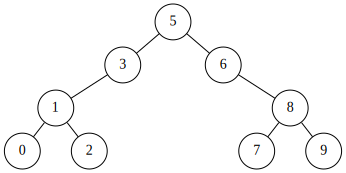

In [ ]:
arbolOLDE = ArbolOLDE()
arbolOLDE.dibujar()

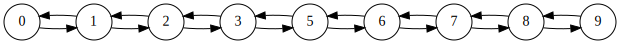

In [ ]:
arbolOLDE.a_lista_doble_enlace()
arbolOLDE.dibujar_lista_doble_enlace()

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


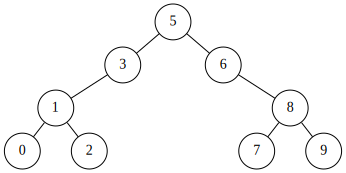

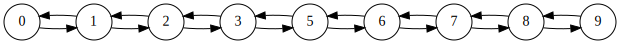

In [ ]:
import aed_utilities as aed

#######################################################################
# Esto lo consideramos como «asumido»
class NodoLDE:  # Nodo lista doble enlace
    def __init__(self, prev, info, sgte):
        self.prev=prev
        self.info=info
        self.sgte=sgte

class Lista_doble_enlace:
    def __init__(self):
        self.cabecera=NodoLDE(None,0,None)
        self.cabecera.prev=self.cabecera
        self.cabecera.sgte=self.cabecera

    def insertar_despues_de(self,p,info): # inserta después de nodo p
        r=p.sgte
        p.sgte=r.prev=NodoLDE(p,info,r)

    def eliminar(self,p): # elimina el nodo p
        assert p is not self.cabecera
        (p.prev.sgte,p.sgte.prev)=(p.sgte,p.prev)

    def k_esimo(self,k): # retorna k-esimo nodo, o None si fuera de rango
        p=self.cabecera
        j=0
        while True:
            if j==k:
                return p
            p=p.sgte
            if p is self.cabecera:
                return None
            j+=1

    def ascendente(self):
        p=self.cabecera.sgte
        while p is not self.cabecera:
            yield p.info
            p=p.sgte

    def descendente(self):
        p=self.cabecera.prev
        while p is not self.cabecera:
            yield p.info
            p=p.prev

    def get_primero(self):
        return self.cabecera.sgte

    def get_ultimo(self):
        return self.cabecera.prev

    # Para dibujar una lista doblemente enlazada, es necesario además definir el nombre del campo del puntero hacia atrás.
    # El parámetro para definir ese campo es "fieldReverseLink". Por default, este campo es None.
    def dibujar(self):
        lld=aed.LinkedListDrawer(fieldHeader="cabecera", fieldData="info", fieldLink="sgte", fieldReverseLink="prev")
        lld.draw_double_linked_list(self)


class NodoArbol:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

class ArbolOLDE:
    def __init__(self,raiz=None):
        if raiz is None:
            self.raiz = NodoArbol(NodoArbol(NodoArbol(NodoArbol(None, 0, None),
                                                      1,
                                                      NodoArbol(None, 2, None)),
                                            3,
                                            #NodoArbol(None, 4, None)),
                                            None),
                                  5,
                                  NodoArbol(None,
                                            6,
                                            NodoArbol(NodoArbol(None, 7, None),
                                                      8,
                                                      NodoArbol(None, 9, None))))
        else:
            self.raiz = raiz

    #######################################################################
    # Aquí empezamos nuestra solución
    #######################################################################

    # Solución:
    def a_lista_doble_enlace(self):
        # creamos variables de estado para el recorrido
        # head: el primero de la lista
        self.head = None
        # prev: el que irá avanzando (último añadido al anticucho)
        self.prev = None

        # Función auxiliar que hace el recorrido
        # esta es la función CLAVE
        self.lista_doble_enlace(self.raiz)

        # Ahora, solo arreglamos para que quede bien formateado
        self.cabecera = NodoArbol(None, 0, None)

        # Cerramos conectando los extremos
        # Caso que el arbol estaba vacío:
        if self.head is None:
            self.cabecera.der = self.cabecera
            self.cabecera.izq = self.cabecera
        # Caso que el árbol no estaba vacío
        else:
            # head quedó como el primero,
            # prev quedó como el último que agragamos (ahora el último global)

            # Cabecera conecta en der con el primero (head), en izq con el
            # último (prev)
            self.cabecera.der = self.head
            self.cabecera.izq = self.prev

            # Ahora, el primero (head) debe conectar con cabecera
            # el último (prev) también, pero por el otro lado
            self.cabecera.der.izq = self.cabecera
            self.cabecera.izq.der = self.cabecera



    def lista_doble_enlace(self, nodo):
        # Caso Base: nodo es None
        if nodo is None:
            return

        # inorden: izq, raiz, der
        self.lista_doble_enlace(nodo.izq)

        # Si self.prev es None, quiere decir que no hemos empezado el anticucho
        if self.prev is None:
           self.head = nodo
        else:
          # crear punteros de la lista
          self.prev.der = nodo
          nodo.izq = self.prev

        # Avanzar el prev y seguir con lado derecho
        self.prev = nodo
        self.lista_doble_enlace(nodo.der)

    #######################################################################
    # Fin de nuestra solución
    #######################################################################

    # Para dibujar un árbol binario, necesitamos crear una instancia de la clase BinaryTreeDrawer
    # Aquí también necesitamos conocer la estructura de los nodos. Esta información se envía como parámetro
    # al constructor de la clase:
    #    - fieldData: nombre del campo del nodo que mantiene la data
    #    - fieldLeft: nombre del campo del nodo con el puntero izquierdo
    #    - fieldRight: nombre del campo del noso con le puntero derecho
    # Para dibujar se llama al método "draw_tree", enviando como parámetro el árbol binario y el nombre del campo que identifica al nodo raiz.
    def dibujar(self):
        btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der")
        btd.draw_tree(self, "raiz")

    # b)
    def dibujar_lista_doble_enlace(self):
        lld = aed.LinkedListDrawer(fieldHeader="cabecera", fieldData="info", fieldLink="der", fieldReverseLink="izq")
        lld.draw_double_linked_list(self)

l=Lista_doble_enlace()
for i in range(20):
    l.insertar_despues_de(l.k_esimo(i), i+1)
print([x for x in l.ascendente()])

arbolOLDE = ArbolOLDE()
arbolOLDE.dibujar()

arbolOLDE.a_lista_doble_enlace()
arbolOLDE.dibujar_lista_doble_enlace()